## Time-Series Autoencoder for Suspicious Financial Transaction Periods

---

## 1. Project Introduction

This notebook applies a **time-series autoencoder** to financial transaction data.

In the previous anomaly detection notebook, we detected suspicious transactions at the individual transaction level.

In this notebook, we move one level higher.

Instead of asking:

> Is this single transaction suspicious?

we ask:

> Is this transaction period suspicious?

---

## Business Context

Financial fraud may not always appear as one isolated transaction.

Sometimes suspicious behaviour appears as a pattern over time.

Examples:

| Situation | Business Meaning |
|---|---|
| Sudden increase in transfer amount | Possible unusual money movement |
| High number of cash-out transactions | Possible suspicious withdrawal behaviour |
| Sharp increase in fraud rate | Possible attack period |
| Abnormal transaction volume | Possible system or fraud event |
| Unusual mix of transaction types | Behaviour shift needing investigation |

A time-series autoencoder can help detect unusual transaction periods by learning normal behaviour across time.

---

## Dataset Used

We use the same **PaySim financial transaction dataset**.

However, we use it differently.

In the previous notebook:

`one row = one transaction`

In this notebook:

`one sample = one time window`

The `step` column in PaySim allows us to convert raw transaction rows into time-based summaries.

---

## Main Idea

We first aggregate transactions by time step.

Then we create rolling time windows.

The model learns normal transaction behaviour across a sequence of time steps.

If a time window is reconstructed badly, it may represent an unusual or suspicious period.

---

## Machine Learning Workflow

The workflow is:

`raw transactions → aggregate by step → create time-series features → build sliding windows → train LSTM autoencoder → calculate reconstruction error → flag suspicious time windows`

---

## Main Business Question

This notebook answers:

> Can a time-series autoencoder learn normal transaction behaviour over time and detect suspicious transaction periods?

---

## What We Will Learn

By the end of this notebook, we will understand:

| Concept | Simple Meaning |
|---|---|
| Time series | Data ordered by time |
| Time step | One point or period in time |
| Aggregation | Summarising many transaction rows into one time period |
| Sliding window | A moving group of time steps |
| Sequence | A time-ordered block of data |
| LSTM | Neural network layer that learns sequence patterns |
| LSTM autoencoder | Autoencoder that reconstructs time windows |
| Sequence reconstruction error | How badly the model rebuilds a time window |
| Suspicious period | A time window with unusually high reconstruction error |

---

## Important Note

The fraud columns will not be used as model input.

They will be used only later for evaluation and business interpretation.

The model should learn transaction behaviour patterns, not cheat using fraud labels.

## 2. Theory Recap: Time-Series Autoencoder

Before coding, we summarise the main idea.

A time series is data ordered by time.

In this project, the `step` column represents time.

Instead of looking at one transaction row at a time, we create summaries for each time step.

Then we create sliding windows from those time steps.

---

### Key Idea

A normal autoencoder reconstructs one row.

A time-series autoencoder reconstructs a full sequence.

| Model Type | Input | Output |
|---|---|---|
| Dense autoencoder | One transaction row | Reconstructed transaction row |
| Time-series autoencoder | A sequence of time steps | Reconstructed sequence |

---

### Sliding Window

A sliding window creates many sequences from ordered time data.

Example with window size 5:

`steps 1–5 → window 1`

`steps 2–6 → window 2`

`steps 3–7 → window 3`

Each window becomes one training sample.

---

### LSTM Autoencoder

An LSTM autoencoder has two main parts:

| Part | Purpose |
|---|---|
| LSTM encoder | Reads the time sequence and compresses it |
| LSTM decoder | Rebuilds the original time sequence |

The model learns to reconstruct normal transaction periods.

If a time window is reconstructed badly, it may be suspicious.

---

### Reconstruction Error

The reconstruction error measures how different the reconstructed sequence is from the original sequence.

Simple logic:

`normal time window → low reconstruction error`

`suspicious time window → high reconstruction error`

---

### Important Rule

The fraud columns are not used as model input.

They are used later only for evaluation and business interpretation.

The model should learn normal transaction behaviour over time, not directly learn the fraud labels.

## 3. Environment Setup

This section imports the libraries needed for the time-series autoencoder workflow.

We use:

| Library | Purpose |
|---|---|
| NumPy | Numerical calculations |
| Pandas | Data handling and aggregation |
| Matplotlib | BI-ready charts |
| TensorFlow / Keras | LSTM autoencoder model |
| Scikit-learn | Scaling and train-test preparation |

We also set random seeds to make results more stable when the notebook is re-run.

In [1]:
# ============================================================
# Step 3: Environment Setup and Imports
# ============================================================

# Core libraries
import numpy as np
import pandas as pd

# Charting
import matplotlib.pyplot as plt

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Preprocessing
from sklearn.preprocessing import StandardScaler

# File handling
from pathlib import Path

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

2026-06-08 17:10:59.173753: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully.
TensorFlow version: 2.16.2
Pandas version: 3.0.3
NumPy version: 1.26.4


## 4. Load the PaySim Dataset

Now we load the PaySim financial transaction dataset.

This is the same dataset used in the previous anomaly detection notebook.

In this notebook, we will not model each transaction row directly.

Instead, we will use the `step` column to create time-based transaction summaries.

The raw dataset is loaded first, then we aggregate it by time step.

In [2]:
# ============================================================
# Step 4: Load the PaySim Dataset
# ============================================================

# Local dataset folder
data_path = Path("data/paysim")

# Find CSV files inside the dataset folder
csv_files = list(data_path.glob("*.csv"))

print("CSV files found:", len(csv_files))

for file in csv_files:
    print("-", file.name)

# Safety check
if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file found in data/paysim. "
        "Please check that the PaySim dataset is downloaded and unzipped."
    )

# Load dataset
transactions = pd.read_csv(csv_files[0])

print("\nDataset loaded successfully.")
print("Rows:", transactions.shape[0])
print("Columns:", transactions.shape[1])

display(transactions.head())

CSV files found: 1
- PS_20174392719_1491204439457_log.csv

Dataset loaded successfully.
Rows: 6362620
Columns: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 5. Dataset Structure Check

Before aggregation, we quickly inspect the raw dataset structure.

This confirms that the key columns needed for time-series preparation are available.

Important columns:

| Column | Purpose |
|---|---|
| `step` | Time unit used for aggregation |
| `type` | Transaction type |
| `amount` | Transaction amount |
| `isFraud` | Fraud label for evaluation only |

In [3]:
# ============================================================
# Step 5: Dataset Structure Check
# ============================================================

print("Dataset shape:", transactions.shape)

print("\nData types:")
display(transactions.dtypes.to_frame(name="Data Type"))

print("\nMissing values:")
missing_summary = (
    transactions
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["Column", "Missing Values"]
missing_summary["Missing %"] = (
    missing_summary["Missing Values"] / len(transactions) * 100
).round(4)

display(missing_summary)

print("\nUnique time steps:", transactions["step"].nunique())
print("Minimum step:", transactions["step"].min())
print("Maximum step:", transactions["step"].max())

Dataset shape: (6362620, 11)

Data types:


,Data Type
step,int64
type,str
amount,float64
nameOrig,str
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,str
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64



Missing values:


,Column,Missing Values,Missing %
0,step,0,0.0
1,type,0,0.0
2,amount,0,0.0
3,nameOrig,0,0.0
4,oldbalanceOrg,0,0.0
5,newbalanceOrig,0,0.0
6,nameDest,0,0.0
7,oldbalanceDest,0,0.0
8,newbalanceDest,0,0.0
9,isFraud,0,0.0



Unique time steps: 743
Minimum step: 1
Maximum step: 743


## 6A. Create Amount-Based Time-Step Summary

The raw dataset has one row per transaction.

For the time-series autoencoder, we need one row per time step.

In this step, we group transactions by `step` and calculate basic transaction amount KPIs.

These KPIs describe what happened during each time period.

In [4]:
# ============================================================
# Step 6A: Create Amount-Based Time-Step Summary
# ============================================================

# Group raw transaction rows by the time column: step
# Each group represents one time period in the PaySim dataset.
step_amount_summary = (
    transactions
    .groupby("step")
    .agg(
        transaction_count=("amount", "count"),   # number of transactions in this step
        total_amount=("amount", "sum"),          # total money moved in this step
        average_amount=("amount", "mean"),       # average transaction amount in this step
        max_amount=("amount", "max"),            # largest transaction amount in this step
        fraud_count=("isFraud", "sum")           # fraud count for evaluation only, not model input
    )
    .reset_index()                               # convert step from index back into a normal column
)

print("Amount-based time-step summary created successfully.")
print("Rows:", step_amount_summary.shape[0])
print("Columns:", step_amount_summary.shape[1])

display(step_amount_summary.head())

Amount-based time-step summary created successfully.
Rows: 743
Columns: 6


,step,transaction_count,total_amount,average_amount,max_amount,fraud_count
0,1,2708,2.854292e+08,105402.208696,3776389.09,16
1,2,1014,8.592160e+07,84735.309684,2474181.78,8
2,3,552,4.329388e+07,78430.950036,2837270.65,4
3,4,565,7.291003e+07,129044.298354,10000000.00,10
4,5,665,4.554809e+07,68493.368045,1915470.93,6


In [5]:
# ============================================================
# Step 6B: Count Transaction Types per Time Step
# ============================================================

# Create one column per transaction type
# Each value shows how many times that transaction type appeared in the step.
type_counts = (
    transactions
    .pivot_table(
        index="step",          # one row per time step
        columns="type",        # one column per transaction type
        values="amount",       # use amount only to count rows
        aggfunc="count",       # count transactions
        fill_value=0           # if a type is missing in a step, fill with 0
    )
    .reset_index()
)

# Remove pivot table column group name
type_counts.columns.name = None

# Rename columns into clean snake_case names
type_counts = type_counts.rename(columns={
    "CASH_IN": "cash_in_count",
    "CASH_OUT": "cash_out_count",
    "DEBIT": "debit_count",
    "PAYMENT": "payment_count",
    "TRANSFER": "transfer_count"
})

print("Transaction type counts created successfully.")
print("Rows:", type_counts.shape[0])
print("Columns:", type_counts.shape[1])

display(type_counts.head())

Transaction type counts created successfully.
Rows: 743
Columns: 6


,step,cash_in_count,cash_out_count,debit_count,payment_count,transfer_count
0,1,527,388,148,1369,276
1,2,203,104,71,555,81
2,3,124,52,25,316,35
3,4,136,77,16,294,42
4,5,131,61,24,419,30


## 6C. Combine Time-Step Summaries

Now we combine:

- amount-based KPIs,
- transaction type counts.

This creates one complete time-series table where each row describes one time step.

In [6]:
# ============================================================
# Step 6C: Combine Time-Step Summaries
# ============================================================

# Merge amount summary and transaction type counts using step
step_data = step_amount_summary.merge(
    type_counts,
    on="step",
    how="left"
)

print("Time-step summaries combined successfully.")
print("Rows:", step_data.shape[0])
print("Columns:", step_data.shape[1])

display(step_data.head())

Time-step summaries combined successfully.
Rows: 743
Columns: 11


,step,transaction_count,total_amount,average_amount,max_amount,fraud_count,cash_in_count,cash_out_count,debit_count,payment_count,transfer_count
0,1,2708,2.854292e+08,105402.208696,3776389.09,16,527,388,148,1369,276
1,2,1014,8.592160e+07,84735.309684,2474181.78,8,203,104,71,555,81
2,3,552,4.329388e+07,78430.950036,2837270.65,4,124,52,25,316,35
3,4,565,7.291003e+07,129044.298354,10000000.00,10,136,77,16,294,42
4,5,665,4.554809e+07,68493.368045,1915470.93,6,131,61,24,419,30


## 6D. Create Fraud Rate and Transaction Type Share Features

Now we create extra time-step features.

First, we create `fraud_rate`.

This shows the share of transactions that were fraud in each time step.

Important:

`fraud_rate` is used only for evaluation and interpretation.

It is not used as model input.

Then we create transaction type share features.

For example:

`cash_out_share = cash_out_count / transaction_count`

These share features show the transaction mix in each time step.

In [ ]:
# ============================================================
# Step 6D: Create Fraud Rate and Transaction Type Share Features
# ============================================================

# Fraud rate tells us what share of transactions were fraud in each time step.
# This is used only later for evaluation and business interpretation.
step_data["fraud_rate"] = (
    step_data["fraud_count"] / step_data["transaction_count"]
)

# These are the transaction type count columns created in Step 6B.

type_count_columns = [
    "cash_in_count",
    "cash_out_count",
    "debit_count",
    "payment_count",
    "transfer_count"
]

# Convert each transaction type count into a share of total transactions.
# Example: cash_out_share = cash_out_count / transaction_count

for column in type_count_columns:
    share_column = column.replace("_count", "_share")
    step_data[share_column] = (
        step_data[column] / step_data["transaction_count"]
    )

# Sort by time step so the data is in correct time-series order.
step_data = step_data.sort_values("step").reset_index(drop=True)

print("Fraud rate and transaction type share features created successfully.")
print("Rows:", step_data.shape[0])
print("Columns:", step_data.shape[1])

display(step_data.head())

Fraud rate and transaction type share features created successfully.
Rows: 743
Columns: 17


,step,transaction_count,total_amount,average_amount,max_amount,fraud_count,cash_in_count,cash_out_count,debit_count,payment_count,transfer_count,fraud_rate,cash_in_share,cash_out_share,debit_share,payment_share,transfer_share
0,1,2708,2.854292e+08,105402.208696,3776389.09,16,527,388,148,1369,276,0.005908,0.194609,0.143279,0.054653,0.505539,0.101920
1,2,1014,8.592160e+07,84735.309684,2474181.78,8,203,104,71,555,81,0.007890,0.200197,0.102564,0.070020,0.547337,0.079882
2,3,552,4.329388e+07,78430.950036,2837270.65,4,124,52,25,316,35,0.007246,0.224638,0.094203,0.045290,0.572464,0.063406
3,4,565,7.291003e+07,129044.298354,10000000.00,10,136,77,16,294,42,0.017699,0.240708,0.136283,0.028319,0.520354,0.074336
4,5,665,4.554809e+07,68493.368045,1915470.93,6,131,61,24,419,30,0.009023,0.196992,0.091729,0.036090,0.630075,0.045113


### Time-Step Feature Engineering — Conclusion

The raw transaction dataset was converted into a time-series dataset.

The original dataset had:

`one row = one transaction`

The new dataset has:

`one row = one time step`

Each time step now contains summary features such as:

| Feature Group | Examples |
|---|---|
| Transaction volume | `transaction_count` |
| Amount behaviour | `total_amount`, `average_amount`, `max_amount` |
| Fraud evaluation columns | `fraud_count`, `fraud_rate` |
| Transaction type counts | `cash_out_count`, `transfer_count`, `payment_count` |
| Transaction type shares | `cash_out_share`, `transfer_share`, `payment_share` |

The fraud columns are kept only for evaluation and business interpretation.

They will not be used as model input.

This step prepares the data for time-window creation.

## 7. Select Model Features and Evaluation Columns

Now we separate model input features from evaluation columns.

The model should learn normal transaction behaviour over time.

So we use transaction behaviour columns as input.

Fraud-related columns are kept separately for evaluation.

Important:

`fraud_count` and `fraud_rate` are not used as model input.

They are used later to check whether high-error windows match suspicious fraud-heavy periods.

In [ ]:
# ============================================================
# Step 7: Select Model Features and Evaluation Columns
# ============================================================

# These columns describe transaction behaviour over time.
# They are used as input features for the time-series autoencoder.

time_series_feature_columns = [
    "transaction_count",
    "total_amount",
    "average_amount",
    "max_amount",
    "cash_in_share",
    "cash_out_share",
    "debit_share",
    "payment_share",
    "transfer_share"
]

# These columns are used only after modelling for evaluation and interpretation.
evaluation_columns = [
    "step",
    "fraud_count",
    "fraud_rate"
]

# Create feature table for modelling

time_series_features = step_data[time_series_feature_columns].copy()

# Create evaluation table for later business interpretation

time_series_evaluation = step_data[evaluation_columns].copy()

print("Model feature columns:")
print(time_series_feature_columns)

print("\nEvaluation columns:")
print(evaluation_columns)

print("\nFeature data shape:", time_series_features.shape)
print("Evaluation data shape:", time_series_evaluation.shape)

display(time_series_features.head())

Model feature columns:
['transaction_count', 'total_amount', 'average_amount', 'max_amount', 'cash_in_share', 'cash_out_share', 'debit_share', 'payment_share', 'transfer_share']

Evaluation columns:
['step', 'fraud_count', 'fraud_rate']

Feature data shape: (743, 9)
Evaluation data shape: (743, 3)


,transaction_count,total_amount,average_amount,max_amount,cash_in_share,cash_out_share,debit_share,payment_share,transfer_share
0,2708,2.854292e+08,105402.208696,3776389.09,0.194609,0.143279,0.054653,0.505539,0.101920
1,1014,8.592160e+07,84735.309684,2474181.78,0.200197,0.102564,0.070020,0.547337,0.079882
2,552,4.329388e+07,78430.950036,2837270.65,0.224638,0.094203,0.045290,0.572464,0.063406
3,565,7.291003e+07,129044.298354,10000000.00,0.240708,0.136283,0.028319,0.520354,0.074336
4,665,4.554809e+07,68493.368045,1915470.93,0.196992,0.091729,0.036090,0.630075,0.045113


In [9]:
# ============================================================
# Step 7: Select Model Features and Evaluation Columns
# ============================================================

# These columns describe transaction behaviour over time.
# They are used as input features for the time-series autoencoder.
time_series_feature_columns = [
    "transaction_count",
    "total_amount",
    "average_amount",
    "max_amount",
    "cash_in_share",
    "cash_out_share",
    "debit_share",
    "payment_share",
    "transfer_share"
]

# These columns are used only after modelling for evaluation and interpretation.
evaluation_columns = [
    "step",
    "fraud_count",
    "fraud_rate"
]

# Create feature table for modelling
time_series_features = step_data[time_series_feature_columns].copy()

# Create evaluation table for later business interpretation
time_series_evaluation = step_data[evaluation_columns].copy()

print("Model feature columns:")
print(time_series_feature_columns)

print("\nEvaluation columns:")
print(evaluation_columns)

print("\nFeature data shape:", time_series_features.shape)
print("Evaluation data shape:", time_series_evaluation.shape)

display(time_series_features.head())

Model feature columns:
['transaction_count', 'total_amount', 'average_amount', 'max_amount', 'cash_in_share', 'cash_out_share', 'debit_share', 'payment_share', 'transfer_share']

Evaluation columns:
['step', 'fraud_count', 'fraud_rate']

Feature data shape: (743, 9)
Evaluation data shape: (743, 3)


,transaction_count,total_amount,average_amount,max_amount,cash_in_share,cash_out_share,debit_share,payment_share,transfer_share
0,2708,2.854292e+08,105402.208696,3776389.09,0.194609,0.143279,0.054653,0.505539,0.101920
1,1014,8.592160e+07,84735.309684,2474181.78,0.200197,0.102564,0.070020,0.547337,0.079882
2,552,4.329388e+07,78430.950036,2837270.65,0.224638,0.094203,0.045290,0.572464,0.063406
3,565,7.291003e+07,129044.298354,10000000.00,0.240708,0.136283,0.028319,0.520354,0.074336
4,665,4.554809e+07,68493.368045,1915470.93,0.196992,0.091729,0.036090,0.630075,0.045113


### Feature Selection — Conclusion

The time-series model input features were selected.

The model will use transaction behaviour features such as:

| Feature Group | Columns |
|---|---|
| Volume | `transaction_count` |
| Amount behaviour | `total_amount`, `average_amount`, `max_amount` |
| Transaction mix | `cash_in_share`, `cash_out_share`, `debit_share`, `payment_share`, `transfer_share` |

Fraud-related columns were kept separately:

| Evaluation Column | Use |
|---|---|
| `fraud_count` | Check how many fraud transactions happened in each step |
| `fraud_rate` | Check fraud intensity in each step |

The fraud columns are not used as model input.

They will be used later to understand whether high-error time windows match suspicious fraud-heavy periods.

## 8. Create Chronological Train, Validation, and Test Sets

For time-series modelling, we must respect time order.

So we do not randomly split the data.

Instead, we split the time steps chronologically:

| Dataset | Time Period | Purpose |
|---|---|---|
| Training set | Earlier time steps | Learn normal historical behaviour |
| Validation set | Middle time steps | Set threshold and check reconstruction |
| Test set | Later time steps | Final anomaly detection evaluation |

This avoids future data leaking into the training process.

In [ ]:
# ============================================================
# Step 8: Chronological Train, Validation, and Test Split
# ============================================================

# Total number of time steps available after aggregation

total_steps = len(time_series_features)

# Define split positions using time order
train_end_index = int(total_steps * 0.70)       # first 70% for training
val_end_index = int(total_steps * 0.85)         # next 15% for validation, final 15% for test

# Split model input features by time order
train_time_features = time_series_features.iloc[:train_end_index].copy()
val_time_features = time_series_features.iloc[train_end_index:val_end_index].copy()
test_time_features = time_series_features.iloc[val_end_index:].copy()

# Split evaluation data using the same time positions
train_time_evaluation = time_series_evaluation.iloc[:train_end_index].copy()
val_time_evaluation = time_series_evaluation.iloc[train_end_index:val_end_index].copy()
test_time_evaluation = time_series_evaluation.iloc[val_end_index:].copy()

print("Chronological split completed.")
print("Total time steps:", total_steps)

print("\nFeature split shapes:")
print("Training:", train_time_features.shape)
print("Validation:", val_time_features.shape)
print("Test:", test_time_features.shape)

print("\nStep ranges:")
print("Training steps:", train_time_evaluation["step"].min(), "to", train_time_evaluation["step"].max())
print("Validation steps:", val_time_evaluation["step"].min(), "to", val_time_evaluation["step"].max())
print("Test steps:", test_time_evaluation["step"].min(), "to", test_time_evaluation["step"].max())

print("\nFraud summary by split:")
split_fraud_summary = pd.DataFrame({
    "Split": ["Training", "Validation", "Test"],
    "Fraud Count": [
        train_time_evaluation["fraud_count"].sum(),
        val_time_evaluation["fraud_count"].sum(),
        test_time_evaluation["fraud_count"].sum()
    ],
    "Average Fraud Rate": [
        train_time_evaluation["fraud_rate"].mean(),
        val_time_evaluation["fraud_rate"].mean(),
        test_time_evaluation["fraud_rate"].mean()
    ]
})

display(split_fraud_summary)

Chronological split completed.
Total time steps: 743

Feature split shapes:
Training: (520, 9)
Validation: (111, 9)
Test: (112, 9)

Step ranges:
Training steps: 1 to 520
Validation steps: 521 to 631
Test steps: 632 to 743

Fraud summary by split:


,Split,Fraud Count,Average Fraud Rate
0,Training,5781,0.390060
1,Validation,1180,0.438283
2,Test,1252,0.668608


### Chronological Split — Conclusion

The time-series data was split by time order.

This is different from normal random splitting.

For time-series modelling, chronological splitting is important because it prevents future information from leaking into the training data.

The split logic is:

| Split | Purpose |
|---|---|
| Training | Learn earlier transaction behaviour |
| Validation | Check reconstruction and set threshold |
| Test | Evaluate suspicious periods on later time steps |

This keeps the workflow realistic for time-based anomaly detection.

## 9. Scale Time-Series Features

The time-series features have very different ranges.

For example:

| Feature | Range Type |
|---|---|
| `total_amount` | Very large money values |
| `cash_out_share` | Small percentage value |
| `transaction_count` | Count value |

Neural networks train better when numeric features are on a similar scale.

We use `StandardScaler`.

Important:

The scaler is fitted only on training data.

Then the same scaler is applied to validation and test data.

This avoids data leakage.

In [13]:
# ============================================================
# Step 9: Scale Time-Series Features
# ============================================================

# StandardScaler learns mean and standard deviation from training data only.
scaler = StandardScaler()

# Fit scaler on training features and transform training features.
train_scaled = scaler.fit_transform(train_time_features)

# Use the same fitted scaler to transform validation and test features.
val_scaled = scaler.transform(val_time_features)
test_scaled = scaler.transform(test_time_features)

print("Feature scaling completed.")
print("Training scaled shape:", train_scaled.shape)
print("Validation scaled shape:", val_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

print("\nScaled feature preview:")
display(
    pd.DataFrame(
        train_scaled,
        columns=time_series_feature_columns
    ).head()
)

Feature scaling completed.
Training scaled shape: (520, 9)
Validation scaled shape: (111, 9)
Test scaled shape: (112, 9)

Scaled feature preview:


,transaction_count,total_amount,average_amount,max_amount,cash_in_share,cash_out_share,debit_share,payment_share,transfer_share
0,-0.604958,-0.608580,-0.603441,-0.417375,0.582157,-1.871971,3.829855,1.287818,-0.721123
1,-0.718974,-0.675120,-0.626441,-0.523036,0.632517,-2.201540,5.077888,1.490455,-0.829874
2,-0.750069,-0.689337,-0.633457,-0.493575,0.852749,-2.269220,3.069428,1.612269,-0.911175
3,-0.749195,-0.679460,-0.577130,0.087610,0.997559,-1.928600,1.691090,1.359640,-0.857238
4,-0.742464,-0.688585,-0.644516,-0.568370,0.603639,-2.289242,2.322271,1.891569,-1.001444


In [14]:
# ============================================================
# Step 9: Scale Time-Series Features
# ============================================================

# StandardScaler learns mean and standard deviation from training data only.
scaler = StandardScaler()

# Fit scaler on training features and transform training features.
train_scaled = scaler.fit_transform(train_time_features)

# Use the same fitted scaler to transform validation and test features.
val_scaled = scaler.transform(val_time_features)
test_scaled = scaler.transform(test_time_features)

print("Feature scaling completed.")
print("Training scaled shape:", train_scaled.shape)
print("Validation scaled shape:", val_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

print("\nScaled feature preview:")
display(
    pd.DataFrame(
        train_scaled,
        columns=time_series_feature_columns
    ).head()
)

Feature scaling completed.
Training scaled shape: (520, 9)
Validation scaled shape: (111, 9)
Test scaled shape: (112, 9)

Scaled feature preview:


,transaction_count,total_amount,average_amount,max_amount,cash_in_share,cash_out_share,debit_share,payment_share,transfer_share
0,-0.604958,-0.608580,-0.603441,-0.417375,0.582157,-1.871971,3.829855,1.287818,-0.721123
1,-0.718974,-0.675120,-0.626441,-0.523036,0.632517,-2.201540,5.077888,1.490455,-0.829874
2,-0.750069,-0.689337,-0.633457,-0.493575,0.852749,-2.269220,3.069428,1.612269,-0.911175
3,-0.749195,-0.679460,-0.577130,0.087610,0.997559,-1.928600,1.691090,1.359640,-0.857238
4,-0.742464,-0.688585,-0.644516,-0.568370,0.603639,-2.289242,2.322271,1.891569,-1.001444


In [15]:
# ============================================================
# Step 10: Create Sliding Windows
# ============================================================

def create_sliding_windows(feature_array, evaluation_table, window_size):
    """
    Create sliding windows from time-ordered feature data.

    Parameters
    ----------
    feature_array:
        Scaled model input features.
        Shape before windowing:
        number_of_time_steps x number_of_features

    evaluation_table:
        Step-level evaluation data.
        This contains step, fraud_count, and fraud_rate.
        It is not used as model input, only for later interpretation.

    window_size:
        Number of consecutive time steps inside one sequence.

    Returns
    -------
    window_features:
        3D array used by the LSTM autoencoder.
        Shape:
        number_of_windows x window_size x number_of_features

    window_evaluation:
        Evaluation table aligned with each window.
        We use the last step of each window as the window reference point.
    """

    window_features = []
    window_evaluation_rows = []

    # Loop through the time series and create one window at a time
    for start_index in range(len(feature_array) - window_size + 1):
        end_index = start_index + window_size

        # Model input window:
        # contains several consecutive time steps
        feature_window = feature_array[start_index:end_index]

        # Evaluation reference:
        # use the final time step of the window
        evaluation_row = evaluation_table.iloc[end_index - 1]

        window_features.append(feature_window)
        window_evaluation_rows.append(evaluation_row)

    # Convert list of windows into NumPy array for LSTM input
    window_features = np.array(window_features)

    # Convert evaluation rows back into a DataFrame
    window_evaluation = pd.DataFrame(window_evaluation_rows).reset_index(drop=True)

    return window_features, window_evaluation


# Number of time steps inside each sequence
window_size = 24

# Create sliding windows for each split
train_windows, train_window_evaluation = create_sliding_windows(
    train_scaled,
    train_time_evaluation,
    window_size
)

val_windows, val_window_evaluation = create_sliding_windows(
    val_scaled,
    val_time_evaluation,
    window_size
)

test_windows, test_window_evaluation = create_sliding_windows(
    test_scaled,
    test_time_evaluation,
    window_size
)

print("Sliding windows created successfully.")

print("\nWindow size:", window_size)

print("\nLSTM input shapes:")
print("Training windows:", train_windows.shape)
print("Validation windows:", val_windows.shape)
print("Test windows:", test_windows.shape)

print("\nMeaning of shape:")
print("(number of windows, time steps per window, features per time step)")

print("\nTest window evaluation preview:")
display(test_window_evaluation.head())

Sliding windows created successfully.

Window size: 24

LSTM input shapes:
Training windows: (497, 24, 9)
Validation windows: (88, 24, 9)
Test windows: (89, 24, 9)

Meaning of shape:
(number of windows, time steps per window, features per time step)

Test window evaluation preview:


,step,fraud_count,fraud_rate
0,655.0,4.0,1.000000
1,656.0,16.0,0.008142
2,657.0,10.0,1.000000
3,658.0,14.0,1.000000
4,659.0,10.0,0.004000


### Sliding Windows — Conclusion

The scaled time-step data was converted into sliding windows.

Each window contains several consecutive time steps.

The model input shape follows this structure:

`number of windows × window size × number of features`

In this notebook:

| Element | Meaning |
|---|---|
| Number of windows | Number of sequence samples created |
| Window size | Number of time steps inside each sequence |
| Features per time step | Transaction behaviour KPIs used as model input |

The evaluation table is aligned with each window using the final step of that window.

This allows us to later compare high reconstruction error windows with fraud count and fraud rate.

## 11. Build the LSTM Autoencoder

Now we build the time-series autoencoder.

The model receives a sequence as input.

The input shape is:

`window size × number of features`

The model structure is:

| Layer | Purpose |
|---|---|
| LSTM encoder | Reads the sequence and compresses it |
| Bottleneck | Stores the compressed sequence pattern |
| RepeatVector | Repeats the compressed pattern for each time step |
| LSTM decoder | Rebuilds the sequence |
| TimeDistributed output | Reconstructs feature values at each time step |

The output sequence has the same shape as the input sequence because the model learns reconstruction.

In [16]:
# ============================================================
# Step 11: Build the LSTM Autoencoder
# ============================================================

# Get input dimensions from training windows
number_of_time_steps = train_windows.shape[1]      # window size
number_of_features = train_windows.shape[2]        # features per time step

# Input layer receives one full time window
sequence_input = keras.Input(
    shape=(number_of_time_steps, number_of_features),
    name="sequence_input"
)

# Encoder:
# Reads the full sequence and compresses it into a smaller hidden representation.
encoded_sequence = layers.LSTM(
    32,
    activation="tanh",
    name="encoder_lstm_32"
)(sequence_input)

# Bottleneck:
# Small compressed representation of the full time window.
bottleneck = layers.Dense(
    16,
    activation="relu",
    name="bottleneck_16"
)(encoded_sequence)

# RepeatVector:
# Repeats the bottleneck representation once for each time step.
# This prepares the compressed pattern for sequence reconstruction.
repeated_context = layers.RepeatVector(
    number_of_time_steps,
    name="repeat_context"
)(bottleneck)

# Decoder:
# Reconstructs the full sequence from the repeated compressed context.
decoded_sequence = layers.LSTM(
    32,
    activation="tanh",
    return_sequences=True,
    name="decoder_lstm_32"
)(repeated_context)

# Output layer:
# Reconstructs all features at each time step.
sequence_output = layers.TimeDistributed(
    layers.Dense(number_of_features),
    name="reconstructed_sequence"
)(decoded_sequence)

# LSTM autoencoder maps input sequence to reconstructed sequence.
lstm_autoencoder = keras.Model(
    inputs=sequence_input,
    outputs=sequence_output,
    name="time_series_lstm_autoencoder"
)

# MSE is used because this is a reconstruction problem.
lstm_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

lstm_autoencoder.summary()

Model: "time_series_lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_32 (LSTM)          │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_16 (Dense)           │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_context (RepeatVector)   │ (None, 24, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_32 (LSTM)          │ (None, 24, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_sequence          │ (None, 24, 9)          │           297 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,473 (48.72 KB)

 Trainable params: 12,473 (48.72 KB)

 Non-trainable params: 0 (0.00 B)

### LSTM Autoencoder Structure — Conclusion

The LSTM autoencoder was built for sequence reconstruction.

The model input shape is:

`window size × number of features`

This means each model sample contains a full time window, not a single row.

The model structure is:

| Part | Purpose |
|---|---|
| LSTM encoder | Reads the full time window |
| Bottleneck | Stores compressed sequence information |
| RepeatVector | Prepares the compressed pattern for reconstruction |
| LSTM decoder | Rebuilds the time window |
| TimeDistributed Dense layer | Reconstructs feature values at every time step |

The model output shape matches the input shape because this is a reconstruction task.

For training:

`input = train_windows`

`target = train_windows`

The model is not trained using fraud labels.

## 12. Train the LSTM Autoencoder

Now we train the LSTM autoencoder.

The model learns to reconstruct normal time-window behaviour.

For this autoencoder:

`input sequence = target sequence`

This means the model receives a time window and tries to rebuild the same time window.

We use validation windows to monitor whether the model is learning smoothly.

We also use `EarlyStopping`.

`EarlyStopping` stops training if validation loss does not improve for several epochs.

This helps avoid unnecessary training and reduces overfitting.

In [17]:
# ============================================================
# Step 12: Train the LSTM Autoencoder
# ============================================================

# EarlyStopping watches validation loss.
# If validation loss does not improve for several epochs, training stops early.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",          # watch validation reconstruction loss
    patience=5,                  # wait 5 epochs before stopping
    restore_best_weights=True    # keep the best model weights
)

# Train the LSTM autoencoder.
# Input and target are the same because this is a reconstruction model.
lstm_training_history = lstm_autoencoder.fit(
    train_windows,               # input: normal time-window sequences
    train_windows,               # target: same sequences reconstructed
    epochs=40,                   # maximum number of training passes
    batch_size=16,               # small batch size because window dataset is not huge
    shuffle=False,               # keep time-window order stable for sequence learning
    validation_data=(
        val_windows,             # validation input
        val_windows              # validation target
    ),
    callbacks=[early_stopping],
    verbose=1
)

print("LSTM autoencoder training completed.")

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.9863 - val_loss: 0.7850
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.9199 - val_loss: 0.7758
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.8703 - val_loss: 0.7690
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8463 - val_loss: 0.7714
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.8269 - val_loss: 0.7740
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8011 - val_loss: 0.7950
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7638 - val_loss: 0.7777
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7349 - val_loss: 0.7376
Epoch 9/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7067 - val_loss: 0.7796
Epoch 10/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6470 - val_loss: 0.7927
Epoch 11/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6094 - val_loss: 0.8208
Epoch 12/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5

## 13. Review LSTM Autoencoder Training Performance

After training, we review the training loss and validation loss.

| Metric | Meaning |
|---|---|
| Training loss | Reconstruction error on training windows |
| Validation loss | Reconstruction error on validation windows |

If both losses decrease and stay close, the model is learning sequence behaviour properly.

If validation loss becomes much higher than training loss, the model may be overfitting.

In [18]:
# ============================================================
# Step 13: Review LSTM Training Performance
# ============================================================

# Convert Keras training history into a DataFrame
lstm_training_history_table = pd.DataFrame(lstm_training_history.history)

# Add epoch number for easier reading
lstm_training_history_table["Epoch"] = range(1, len(lstm_training_history_table) + 1)

# Extract final training and validation loss
final_lstm_training_loss = lstm_training_history_table["loss"].iloc[-1]
final_lstm_validation_loss = lstm_training_history_table["val_loss"].iloc[-1]

print("Final LSTM training loss:", round(final_lstm_training_loss, 6))
print("Final LSTM validation loss:", round(final_lstm_validation_loss, 6))
print("Total epochs trained:", len(lstm_training_history_table))

display(lstm_training_history_table.tail())

Final LSTM training loss: 0.585413
Final LSTM validation loss: 0.742436
Total epochs trained: 13


,loss,val_loss,Epoch
8,0.706655,0.779612,9
9,0.647033,0.792740,10
10,0.609438,0.820783,11
11,0.597060,0.805449,12
12,0.585413,0.742436,13


### LSTM Training Performance — Conclusion

The LSTM autoencoder training completed successfully.

The model trained for **13 epochs** before stopping.

The training loss decreased steadily, which means the model learned to reconstruct training time windows better over time.

The validation loss was higher and more unstable than the training loss.

This suggests that the validation period contains behaviour patterns that are somewhat different from the training period.

This is common in time-series anomaly detection because behaviour can change over time.

The model is now ready to calculate reconstruction error on validation and test windows.

## 14. Visualise LSTM Training and Validation Loss

Now we visualise the LSTM autoencoder training performance.

This chart helps us check:

- whether training loss decreased,
- whether validation loss followed the same pattern,
- and whether there is a gap between training and validation loss.

A validation gap can suggest that later time periods behave differently from earlier training periods.

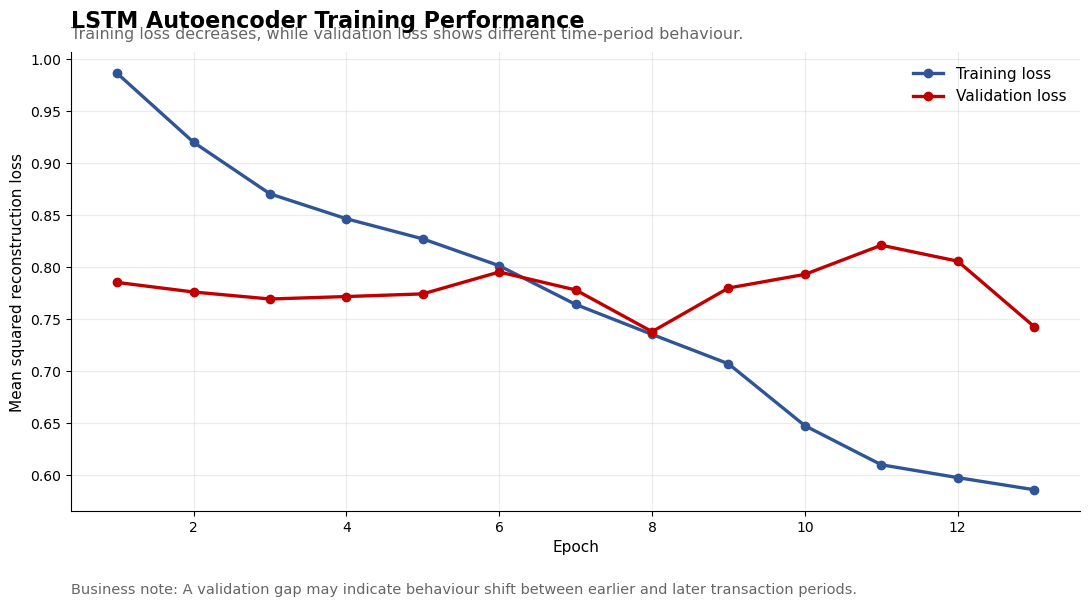

In [19]:
# ============================================================
# Step 14: BI-Ready LSTM Training Loss Chart
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6.2))

ax.plot(
    lstm_training_history_table["Epoch"],
    lstm_training_history_table["loss"],
    marker="o",
    linewidth=2.4,
    label="Training loss",
    color="#2F5597"
)

ax.plot(
    lstm_training_history_table["Epoch"],
    lstm_training_history_table["val_loss"],
    marker="o",
    linewidth=2.4,
    label="Validation loss",
    color="#C00000"
)

ax.set_title(
    "LSTM Autoencoder Training Performance",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.03,
    "Training loss decreases, while validation loss shows different time-period behaviour.",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#666666"
)

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Mean squared reconstruction loss", fontsize=11)

ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0,
    -0.18,
    "Business note: A validation gap may indicate behaviour shift between earlier and later transaction periods.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

plt.tight_layout()
plt.show()

### LSTM Training Loss Chart — Conclusion

The training loss decreased steadily across epochs.

This means the LSTM autoencoder learned to reconstruct the training time windows better over time.

The validation loss was less stable and stayed higher than the training loss.

This suggests that the validation period contains behaviour patterns that differ from the earlier training period.

This is common in time-series anomaly detection because transaction behaviour can shift over time.

The model is still useful for anomaly detection because the main goal is to compare reconstruction error across time windows.

## 15. Calculate Sequence Reconstruction Error

Now we calculate reconstruction error for validation and test windows.

The LSTM autoencoder reconstructs each time window.

Then we compare:

`original window`

with

`reconstructed window`

The result is one reconstruction error value per window.

A high reconstruction error means the model struggled to rebuild that time period.

That window may represent unusual transaction behaviour.

In [20]:
# ============================================================
# Step 15: Calculate Sequence Reconstruction Error
# ============================================================

# Reconstruct validation windows
val_window_reconstructions = lstm_autoencoder.predict(
    val_windows,
    verbose=0
)

# Reconstruct test windows
test_window_reconstructions = lstm_autoencoder.predict(
    test_windows,
    verbose=0
)

# Calculate mean squared reconstruction error per window.
# Axis explanation:
# axis=(1, 2) means:
# 1 = time steps inside the window
# 2 = features inside each time step
val_window_errors = np.mean(
    np.square(val_windows - val_window_reconstructions),
    axis=(1, 2)
)

test_window_errors = np.mean(
    np.square(test_windows - test_window_reconstructions),
    axis=(1, 2)
)

# Store test results in one table for later analysis
test_window_results = test_window_evaluation.copy()
test_window_results["reconstruction_error"] = test_window_errors

print("Sequence reconstruction error calculated successfully.")

print("\nValidation error summary:")
print("Mean:", round(val_window_errors.mean(), 6))
print("Median:", round(np.median(val_window_errors), 6))
print("Max:", round(val_window_errors.max(), 6))

print("\nTest error summary:")
print("Mean:", round(test_window_errors.mean(), 6))
print("Median:", round(np.median(test_window_errors), 6))
print("Max:", round(test_window_errors.max(), 6))

print("\nTest window results preview:")
display(test_window_results.head())

Sequence reconstruction error calculated successfully.

Validation error summary:
Mean: 0.737601
Median: 0.746178
Max: 0.957168

Test error summary:
Mean: 0.669679
Median: 0.669725
Max: 0.94193

Test window results preview:


,step,fraud_count,fraud_rate,reconstruction_error
0,655.0,4.0,1.000000,0.660070
1,656.0,16.0,0.008142,0.697161
2,657.0,10.0,1.000000,0.698707
3,658.0,14.0,1.000000,0.685434
4,659.0,10.0,0.004000,0.695696


### Sequence Reconstruction Error — Conclusion

Sequence reconstruction error was calculated for validation and test windows.

Each reconstruction error value represents how badly the LSTM autoencoder reconstructed one full time window.

The test result table now contains:

| Column | Meaning |
|---|---|
| `step` | Final time step of the window |
| `fraud_count` | Number of fraud transactions at that step |
| `fraud_rate` | Fraud share at that step |
| `reconstruction_error` | Anomaly score for the full time window |

A higher reconstruction error means the model had more difficulty reconstructing that time window.

This can indicate unusual transaction behaviour during that period.

The next step is to set an anomaly threshold using validation reconstruction error.

In [21]:
# ============================================================
# Step 16: Set Anomaly Threshold for Time Windows
# ============================================================

# Use validation reconstruction error to define the anomaly cutoff.
# The 95th percentile means only the highest-error 5% of validation windows define suspicious behaviour.
window_anomaly_threshold = np.percentile(
    val_window_errors,
    95
)

print("Window anomaly threshold created.")
print("Validation error mean:", round(val_window_errors.mean(), 6))
print("Validation error median:", round(np.median(val_window_errors), 6))
print("95th percentile threshold:", round(window_anomaly_threshold, 6))

print("\nAnomaly rule:")
print("If reconstruction_error > threshold, flag the time window as suspicious.")

Window anomaly threshold created.
Validation error mean: 0.737601
Validation error median: 0.746178
95th percentile threshold: 0.877242

Anomaly rule:
If reconstruction_error > threshold, flag the time window as suspicious.


### Time-Window Threshold — Conclusion

The anomaly threshold was calculated using validation reconstruction error.

| Metric | Value |
|---|---:|
| Validation error mean | 0.737601 |
| Validation error median | 0.746178 |
| 95th percentile threshold | 0.877242 |

The selected threshold is **0.877242**.

This means:

`reconstruction_error <= 0.877242 → normal time window`

`reconstruction_error > 0.877242 → suspicious time window`

This threshold identifies time windows that reconstruct worse than most validation windows.

## 17. Flag Suspicious Time Windows

Now we apply the anomaly threshold to the test windows.

Each test window receives a suspicious flag.

| Condition | Result |
|---|---|
| Reconstruction error <= threshold | Normal time window |
| Reconstruction error > threshold | Suspicious time window |

After flagging suspicious windows, we compare them with fraud count and fraud rate.

This helps us understand whether high-error windows are linked to fraud-heavy periods.

In [22]:
# ============================================================
# Step 17: Flag Suspicious Time Windows
# ============================================================

# Apply the threshold to test window reconstruction errors.
# 1 = suspicious window, 0 = normal window
test_window_results["predicted_suspicious_window"] = (
    test_window_results["reconstruction_error"] > window_anomaly_threshold
).astype(int)

# Create readable prediction labels
test_window_results["prediction_label"] = test_window_results["predicted_suspicious_window"].map({
    0: "Predicted Normal Window",
    1: "Predicted Suspicious Window"
})

# Summary of predicted suspicious windows
window_prediction_summary = (
    test_window_results["prediction_label"]
    .value_counts()
    .rename_axis("Prediction")
    .reset_index(name="Windows")
)

window_prediction_summary["Share %"] = (
    window_prediction_summary["Windows"] / len(test_window_results) * 100
).round(3)

print("Suspicious time-window flagging completed.")

display(window_prediction_summary)

print("\nFraud comparison by prediction:")
display(
    test_window_results
    .groupby("prediction_label")
    .agg(
        windows=("step", "count"),
        total_fraud_count=("fraud_count", "sum"),
        average_fraud_rate=("fraud_rate", "mean"),
        average_reconstruction_error=("reconstruction_error", "mean")
    )
    .reset_index()
)

Suspicious time-window flagging completed.


,Prediction,Windows,Share %
0,Predicted Normal Window,75,84.27
1,Predicted Suspicious Window,14,15.73



Fraud comparison by prediction:


,prediction_label,windows,total_fraud_count,average_fraud_rate,average_reconstruction_error
0,Predicted Normal Window,75,836.0,0.689615,0.626308
1,Predicted Suspicious Window,14,146.0,0.364280,0.902025


### Suspicious Window Flagging — Conclusion

The anomaly threshold was applied to the test windows.

The model flagged **14 time windows** as suspicious and **75 time windows** as normal.

| Prediction | Windows | Total Fraud Count | Average Fraud Rate | Average Reconstruction Error |
|---|---:|---:|---:|---:|
| Predicted Normal Window | 75 | 836 | 0.6896 | 0.6263 |
| Predicted Suspicious Window | 14 | 146 | 0.3643 | 0.9020 |

The suspicious windows have a higher average reconstruction error.

This means the LSTM autoencoder identified windows that looked unusual based on transaction behaviour patterns.

However, the suspicious windows do not have a higher average fraud rate than normal windows.

This is an important business finding.

The model is detecting unusual time-period behaviour, but those unusual periods are not automatically the highest fraud-rate periods.

The next step is to visualise reconstruction error over time and compare it with fraud behaviour.

## 18. Visualise Reconstruction Error Over Time

Now we plot reconstruction error across test time steps.

This chart shows when the LSTM autoencoder found unusual behaviour.

We also mark the anomaly threshold.

Windows above the threshold are treated as suspicious.

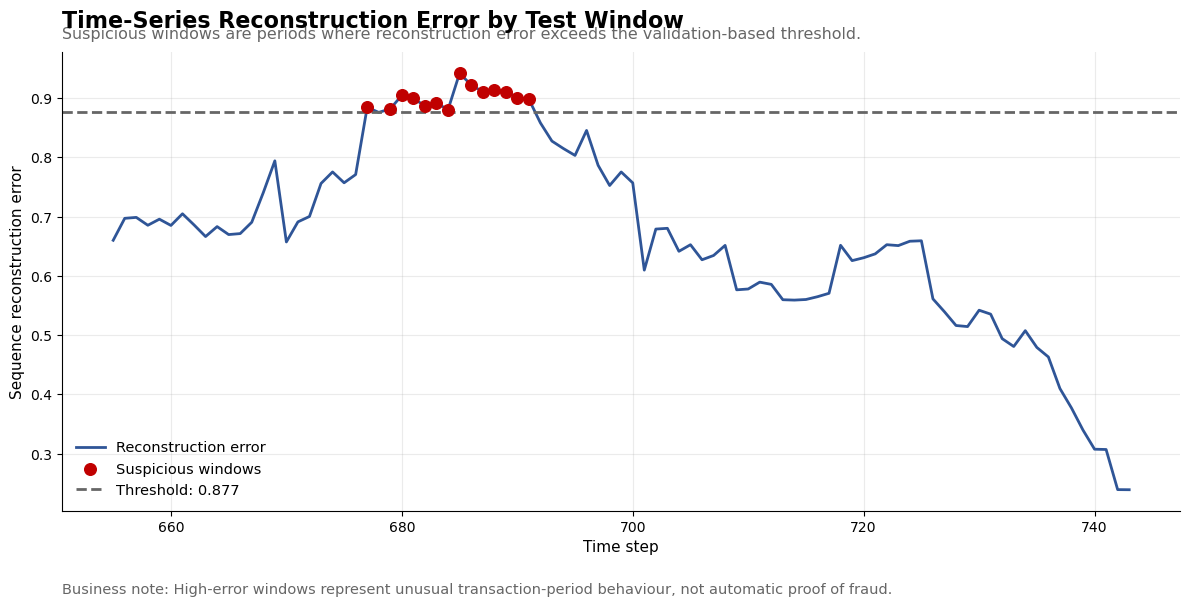

In [23]:
# ============================================================
# Step 18: Reconstruction Error Over Time
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6.2))

normal_windows = test_window_results[
    test_window_results["predicted_suspicious_window"] == 0
]

suspicious_windows = test_window_results[
    test_window_results["predicted_suspicious_window"] == 1
]

ax.plot(
    test_window_results["step"],
    test_window_results["reconstruction_error"],
    linewidth=2.0,
    color="#2F5597",
    label="Reconstruction error"
)

ax.scatter(
    suspicious_windows["step"],
    suspicious_windows["reconstruction_error"],
    color="#C00000",
    s=70,
    label="Suspicious windows",
    zorder=3
)

ax.axhline(
    window_anomaly_threshold,
    linestyle="--",
    linewidth=2,
    color="#666666",
    label=f"Threshold: {window_anomaly_threshold:.3f}"
)

ax.set_title(
    "Time-Series Reconstruction Error by Test Window",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.03,
    "Suspicious windows are periods where reconstruction error exceeds the validation-based threshold.",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#666666"
)

ax.set_xlabel("Time step", fontsize=11)
ax.set_ylabel("Sequence reconstruction error", fontsize=11)

ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=10.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0,
    -0.18,
    "Business note: High-error windows represent unusual transaction-period behaviour, not automatic proof of fraud.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

plt.tight_layout()
plt.show()

### Reconstruction Error Over Time — Conclusion

The reconstruction error chart shows how unusual each test time window was.

The anomaly threshold was set at **0.877**.

Windows above this threshold were flagged as suspicious.

The model identified suspicious windows mainly around:

`steps 678–691`

This means the LSTM autoencoder found unusual transaction-period behaviour during this time range.

After this period, reconstruction error gradually decreased.

This suggests that the later test windows became easier for the model to reconstruct.

Important business interpretation:

High reconstruction error does not automatically prove fraud.

It means the transaction behaviour during that time period was different from the learned normal pattern.

The next step is to compare these suspicious windows with fraud count and fraud rate.

## 19. Compare Reconstruction Error with Fraud Count

Now we compare reconstruction error with fraud count over time.

This helps us check whether suspicious windows overlap with fraud-heavy periods.

The model did not use fraud count as an input feature.

So this comparison is only for business interpretation.

If high reconstruction error appears near high fraud count, the anomaly signal may be useful for fraud monitoring.

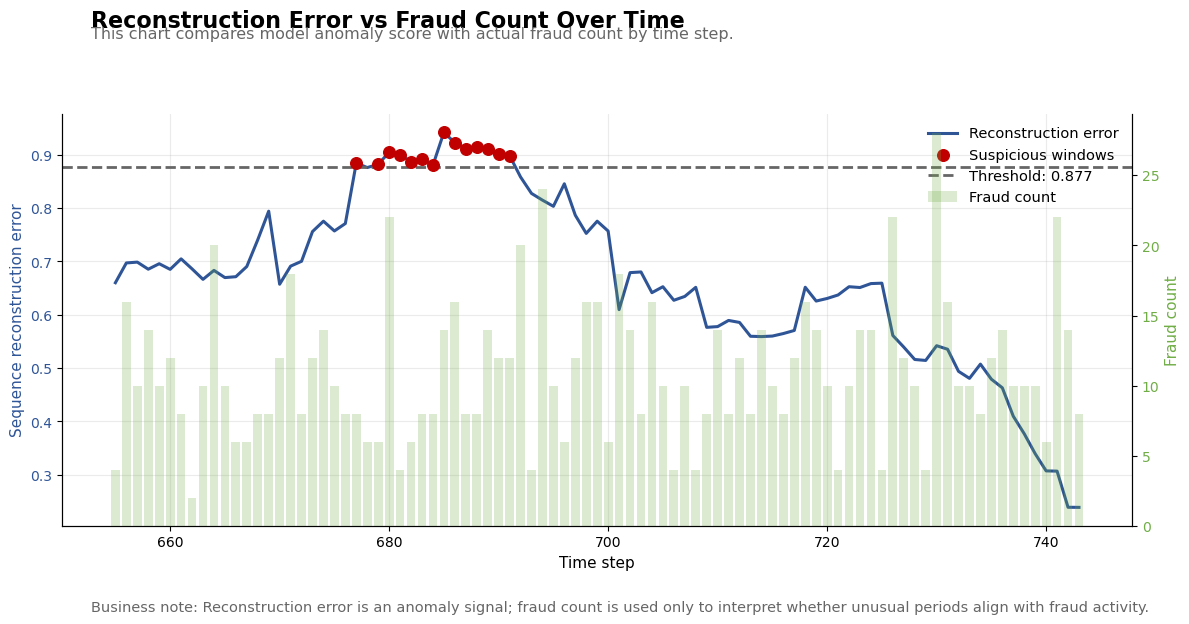

In [24]:
# ============================================================
# Step 19: Compare Reconstruction Error with Fraud Count
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 6.4))

# Line 1: reconstruction error
ax1.plot(
    test_window_results["step"],
    test_window_results["reconstruction_error"],
    linewidth=2.2,
    color="#2F5597",
    label="Reconstruction error"
)

# Suspicious windows as red points
suspicious_windows = test_window_results[
    test_window_results["predicted_suspicious_window"] == 1
]

ax1.scatter(
    suspicious_windows["step"],
    suspicious_windows["reconstruction_error"],
    color="#C00000",
    s=70,
    label="Suspicious windows",
    zorder=3
)

# Threshold line
ax1.axhline(
    window_anomaly_threshold,
    linestyle="--",
    linewidth=2,
    color="#666666",
    label=f"Threshold: {window_anomaly_threshold:.3f}"
)

ax1.set_xlabel("Time step", fontsize=11)
ax1.set_ylabel("Sequence reconstruction error", fontsize=11, color="#2F5597")
ax1.tick_params(axis="y", labelcolor="#2F5597")

# Line 2: fraud count on secondary axis
ax2 = ax1.twinx()

ax2.bar(
    test_window_results["step"],
    test_window_results["fraud_count"],
    alpha=0.25,
    color="#70AD47",
    label="Fraud count"
)

ax2.set_ylabel("Fraud count", fontsize=11, color="#70AD47")
ax2.tick_params(axis="y", labelcolor="#70AD47")

# Title and subtitle
fig.suptitle(
    "Reconstruction Error vs Fraud Count Over Time",
    fontsize=16,
    fontweight="bold",
    x=0.08,
    y=0.98,
    ha="left"
)

fig.text(
    0.08,
    0.935,
    "This chart compares model anomaly score with actual fraud count by time step.",
    fontsize=11.5,
    color="#666666",
    ha="left"
)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=False,
    fontsize=10.5,
    loc="upper right"
)

ax1.grid(alpha=0.25)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

fig.text(
    0.08,
    0.04,
    "Business note: Reconstruction error is an anomaly signal; fraud count is used only to interpret whether unusual periods align with fraud activity.",
    fontsize=10.5,
    color="#666666",
    ha="left"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.90])
plt.show()

### Reconstruction Error vs Fraud Count — Conclusion

This chart compares the LSTM autoencoder anomaly score with actual fraud count over time.

The suspicious windows mainly appear around:

`steps 678–691`

These windows have reconstruction error above the selected threshold.

This means the transaction behaviour during this period looked unusual to the model.

However, fraud count is not concentrated only inside the suspicious window period.

Fraud activity appears across many test steps.

This shows an important difference:

`high reconstruction error = unusual behaviour`

but

`high reconstruction error does not always mean highest fraud count`

The LSTM autoencoder is detecting unusual transaction-period behaviour based on transaction volume, amount patterns, and transaction type mix.

Fraud count is used only for business interpretation after anomaly detection.

## 20. Final Time-Series Anomaly KPI Summary

Now we create a final KPI summary for the time-series anomaly detection result.

This table explains:

- how many windows were analysed,
- how many were flagged as suspicious,
- the average reconstruction error,
- and how fraud activity compares between normal and suspicious windows.

This gives a simple business summary of the model output.

In [ ]:
# ============================================================
# Step 20: Final Time-Series Anomaly KPI Summary
# ============================================================

# Total windows analysed
total_test_windows = len(test_window_results)

# Suspicious and normal window counts

suspicious_window_count = test_window_results["predicted_suspicious_window"].sum()
normal_window_count = total_test_windows - suspicious_window_count

# Share of windows flagged suspicious

suspicious_window_share = suspicious_window_count / total_test_windows * 100

# Average reconstruction error by group

average_error_normal_windows = test_window_results.loc[
    test_window_results["predicted_suspicious_window"] == 0,
    "reconstruction_error"
].mean()

average_error_suspicious_windows = test_window_results.loc[
    test_window_results["predicted_suspicious_window"] == 1,
    "reconstruction_error"
].mean()

# Fraud count and fraud rate by group
total_fraud_normal_windows = test_window_results.loc[
    test_window_results["predicted_suspicious_window"] == 0,
    "fraud_count"
].sum()

total_fraud_suspicious_windows = test_window_results.loc[
    test_window_results["predicted_suspicious_window"] == 1,
    "fraud_count"
].sum()

average_fraud_rate_normal_windows = test_window_results.loc[
    test_window_results["predicted_suspicious_window"] == 0,
    "fraud_rate"
].mean()

average_fraud_rate_suspicious_windows = test_window_results.loc[
    test_window_results["predicted_suspicious_window"] == 1,
    "fraud_rate"
].mean()

# Create summary table
time_series_kpi_summary = pd.DataFrame({
    "KPI": [
        "Total test windows",
        "Predicted normal windows",
        "Predicted suspicious windows",
        "Suspicious window share %",
        "Average error - normal windows",
        "Average error - suspicious windows",
        "Total fraud count - normal windows",
        "Total fraud count - suspicious windows",
        "Average fraud rate - normal windows",
        "Average fraud rate - suspicious windows"
    ],
    "Value": [
        f"{total_test_windows:,.0f}",
        f"{normal_window_count:,.0f}",
        f"{suspicious_window_count:,.0f}",
        f"{suspicious_window_share:.2f}%",
        f"{average_error_normal_windows:.6f}",
        f"{average_error_suspicious_windows:.6f}",
        f"{total_fraud_normal_windows:,.0f}",
        f"{total_fraud_suspicious_windows:,.0f}",
        f"{average_fraud_rate_normal_windows:.6f}",
        f"{average_fraud_rate_suspicious_windows:.6f}"
    ],
    "Business Meaning": [
        "Number of test time windows analysed",
        "Windows below the anomaly threshold",
        "Windows above the anomaly threshold",
        "Share of test windows flagged for investigation",
        "Average anomaly score for normal windows",
        "Average anomaly score for suspicious windows",
        "Fraud count observed in normal windows",
        "Fraud count observed in suspicious windows",
        "Average fraud intensity in normal windows",
        "Average fraud intensity in suspicious windows"
    ]
})

display(time_series_kpi_summary)

,KPI,Value,Business Meaning
0,Total test windows,89,Number of test time windows analysed
1,Predicted normal windows,75,Windows below the anomaly threshold
2,Predicted suspicious windows,14,Windows above the anomaly threshold
3,Suspicious window share %,15.73%,Share of test windows flagged for investigation
4,Average error - normal windows,0.626308,Average anomaly score for normal windows
5,Average error - suspicious windows,0.902025,Average anomaly score for suspicious windows
6,Total fraud count - normal windows,836,Fraud count observed in normal windows
7,Total fraud count - suspicious windows,146,Fraud count observed in suspicious windows
8,Average fraud rate - normal windows,0.689615,Average fraud intensity in normal windows
9,Average fraud rate - suspicious windows,0.364280,Average fraud intensity in suspicious windows


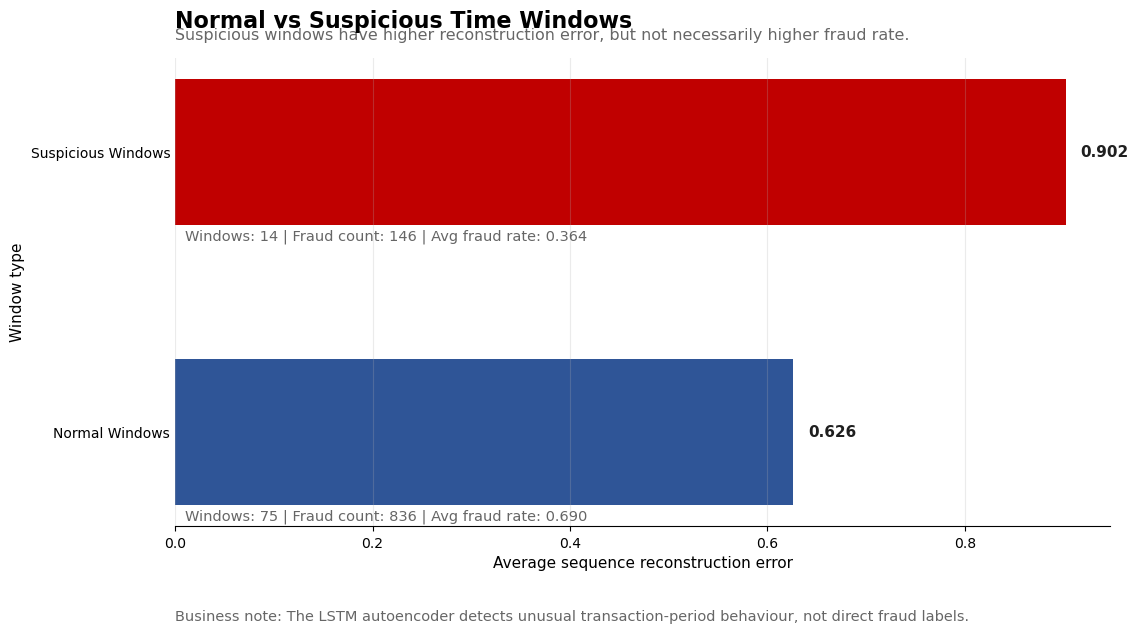

In [26]:
# ============================================================
# Step 21: BI Chart - Normal vs Suspicious Window KPI Comparison
# ============================================================

# Create a compact comparison table for charting
window_group_comparison = (
    test_window_results
    .groupby("prediction_label")
    .agg(
        windows=("step", "count"),
        total_fraud_count=("fraud_count", "sum"),
        average_fraud_rate=("fraud_rate", "mean"),
        average_reconstruction_error=("reconstruction_error", "mean")
    )
    .reset_index()
)

# Clean shorter labels for the chart
window_group_comparison["Window Type"] = window_group_comparison["prediction_label"].replace({
    "Predicted Normal Window": "Normal Windows",
    "Predicted Suspicious Window": "Suspicious Windows"
})

# Sort so normal appears first and suspicious second
window_group_comparison["sort_order"] = window_group_comparison["Window Type"].map({
    "Normal Windows": 1,
    "Suspicious Windows": 2
})

window_group_comparison = (
    window_group_comparison
    .sort_values("sort_order")
    .reset_index(drop=True)
)

# Create figure
fig, ax = plt.subplots(figsize=(11.5, 6.5))

# Main KPI: average reconstruction error
bars = ax.barh(
    window_group_comparison["Window Type"],
    window_group_comparison["average_reconstruction_error"],
    color=["#2F5597", "#C00000"],
    height=0.52
)

# Add value labels on bars
for bar, error_value in zip(
    bars,
    window_group_comparison["average_reconstruction_error"]
):
    ax.text(
        bar.get_width() + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{error_value:.3f}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#1F1F1F"
    )

# Add fraud context as text labels on the left side of each row
for index, row in window_group_comparison.iterrows():
    ax.text(
        0.01,
        index - 0.30,
        f"Windows: {row['windows']:.0f} | Fraud count: {row['total_fraud_count']:.0f} | Avg fraud rate: {row['average_fraud_rate']:.3f}",
        fontsize=10.5,
        color="#666666",
        va="center"
    )

# Chart title and subtitle
ax.set_title(
    "Normal vs Suspicious Time Windows",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=22
)

ax.text(
    0,
    1.04,
    "Suspicious windows have higher reconstruction error, but not necessarily higher fraud rate.",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#666666"
)

# Axis formatting
ax.set_xlabel("Average sequence reconstruction error", fontsize=11)
ax.set_ylabel("Window type", fontsize=11)

ax.grid(axis="x", alpha=0.25)
ax.tick_params(axis="y", length=0)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Business note
ax.text(
    0,
    -0.20,
    "Business note: The LSTM autoencoder detects unusual transaction-period behaviour, not direct fraud labels.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

plt.tight_layout()
plt.show()

## 21. BI Chart: Normal vs Suspicious Window KPI Comparison

Now we visualise the key business difference between normal and suspicious time windows.

The chart compares:

| Metric | Meaning |
|---|---|
| Average reconstruction error | How unusual the windows looked to the model |
| Average fraud rate | Average fraud intensity in the windows |

The chart also adds window count and fraud count as context.

This helps explain whether the LSTM autoencoder anomaly signal matches fraud behaviour.

### KPI Comparison Chart — Conclusion

The KPI comparison chart shows that suspicious windows have a higher average reconstruction error.

This confirms that the LSTM autoencoder successfully identified unusual time-window behaviour.

However, suspicious windows have a lower average fraud rate than normal windows.

| Window Type | Average Error | Average Fraud Rate |
|---|---:|---:|
| Normal Windows | 0.626308 | 0.689615 |
| Suspicious Windows | 0.902025 | 0.364280 |

This means the model is not directly detecting the highest fraud-rate periods.

Instead, it is detecting unusual transaction-period behaviour based on transaction volume, amount patterns, and transaction type mix.

This is still useful as a monitoring signal, but it should not be interpreted as direct fraud classification.

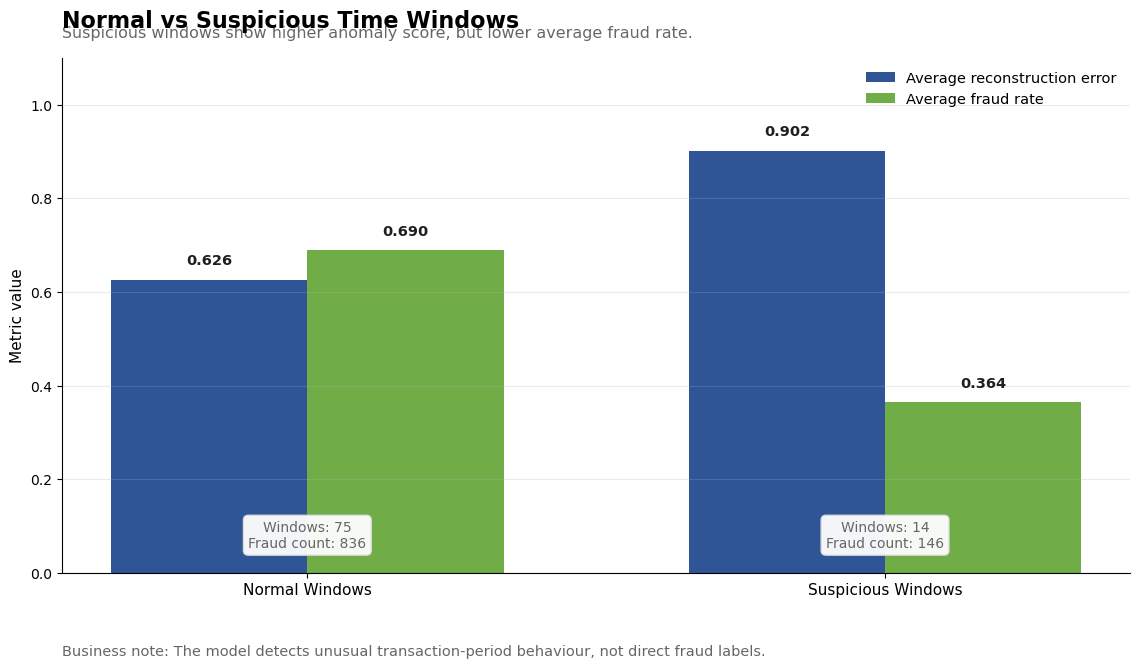

In [28]:
# ============================================================
# Step 21: BI Chart - Normal vs Suspicious Window KPI Comparison
# Cleaner version with better label spacing
# ============================================================

# Create compact chart data from test window results
kpi_chart_data = (
    test_window_results
    .groupby("prediction_label")
    .agg(
        windows=("step", "count"),
        total_fraud_count=("fraud_count", "sum"),
        average_fraud_rate=("fraud_rate", "mean"),
        average_reconstruction_error=("reconstruction_error", "mean")
    )
    .reset_index()
)

# Create clean chart labels
kpi_chart_data["window_type"] = kpi_chart_data["prediction_label"].replace({
    "Predicted Normal Window": "Normal Windows",
    "Predicted Suspicious Window": "Suspicious Windows"
})

# Keep normal first and suspicious second
kpi_chart_data["sort_order"] = kpi_chart_data["window_type"].map({
    "Normal Windows": 1,
    "Suspicious Windows": 2
})

kpi_chart_data = (
    kpi_chart_data
    .sort_values("sort_order")
    .reset_index(drop=True)
)

# X-axis positions
x_positions = np.arange(len(kpi_chart_data))
bar_width = 0.34

fig, ax = plt.subplots(figsize=(11.5, 6.8))

# Bar 1: average reconstruction error
error_bars = ax.bar(
    x_positions - bar_width / 2,
    kpi_chart_data["average_reconstruction_error"],
    width=bar_width,
    label="Average reconstruction error",
    color="#2F5597"
)

# Bar 2: average fraud rate
fraud_rate_bars = ax.bar(
    x_positions + bar_width / 2,
    kpi_chart_data["average_fraud_rate"],
    width=bar_width,
    label="Average fraud rate",
    color="#70AD47"
)

# Add value labels above bars
for bar in list(error_bars) + list(fraud_rate_bars):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold",
        color="#1F1F1F"
    )

# Add clean context labels inside the chart area
for index, row in kpi_chart_data.iterrows():
    ax.text(
        index,
        0.08,
        f"Windows: {row['windows']:.0f}\nFraud count: {row['total_fraud_count']:.0f}",
        ha="center",
        va="center",
        fontsize=10,
        color="#666666",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="#DDDDDD",
            alpha=0.95
        )
    )

# Title and subtitle
ax.set_title(
    "Normal vs Suspicious Time Windows",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=22
)

ax.text(
    0,
    1.04,
    "Suspicious windows show higher anomaly score, but lower average fraud rate.",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#666666"
)

# Axis formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(kpi_chart_data["window_type"], fontsize=11)

ax.set_ylabel("Metric value", fontsize=11)
ax.set_ylim(0, 1.10)

ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, fontsize=10.5, loc="upper right")

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Business note
ax.text(
    0,
    -0.16,
    "Business note: The model detects unusual transaction-period behaviour, not direct fraud labels.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

plt.tight_layout()
plt.show()

### KPI Comparison Chart — Conclusion

The KPI comparison chart shows that suspicious windows have a higher average reconstruction error.

This confirms that the LSTM autoencoder identified these windows as unusual.

However, suspicious windows have a lower average fraud rate than normal windows.

| Window Type | Average Error | Average Fraud Rate | Windows | Fraud Count |
|---|---:|---:|---:|---:|
| Normal Windows | 0.626308 | 0.689615 | 75 | 836 |
| Suspicious Windows | 0.902025 | 0.364280 | 14 | 146 |

This means the model is not directly detecting the highest fraud-rate periods.

Instead, it is detecting unusual transaction-period behaviour based on transaction volume, amount patterns, and transaction type mix.

This is still useful as a monitoring signal, but it should not be interpreted as direct fraud classification.